In [202]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

def plot_iv_surface(
    iv_surface: np.ndarray,
    strikes: np.ndarray,
    maturities: np.ndarray,
    xi0_curve: np.ndarray = None,
    xi0_knots_times: np.ndarray = None,
    kind: str = "contour",
    cmap: str = "plasma",
    figsize=(10, 6),
    title: str = "Implied Volatility Surface",
    log_maturity: bool = True,
):
    """
    Plot implied volatility surface with optional ξ₀(t) forward variance curve across maturities.

    Parameters
    ----------
    iv_surface : np.ndarray
        2D implied vol array (n_maturities, n_strikes).
    strikes : np.ndarray
        1D strike grid.
    maturities : np.ndarray
        1D maturity grid.
    xi0_curve : np.ndarray, optional
        Forward variance values corresponding to xi0_knots_times.
    xi0_knots_times : np.ndarray, optional
        Time points for the xi0_curve. If None, assumed to be equally spaced over maturities.
    kind : {"contour", "heatmap"}, default "contour"
        Plot style.
    cmap : str, default "plasma"
        Colormap.
    figsize : tuple, default (10, 6)
        Figure size.
    title : str, default "Implied Volatility Surface"
        Title of the plot.
    log_maturity : bool, default True
        Whether to plot maturities on log scale.
    """

    maturities = np.array(maturities, dtype=float)
    strikes = np.array(strikes, dtype=float)
    K, T = np.meshgrid(strikes, maturities)

    # --- Main IV surface plot ---
    fig, ax = plt.subplots(figsize=figsize)

    if kind == "heatmap":
        im = ax.imshow(
            iv_surface,
            extent=[strikes.min(), strikes.max(), maturities.min(), maturities.max()],
            origin="lower",
            aspect="auto",
            cmap=cmap,
        )
        cbar = fig.colorbar(im, ax=ax, label="Implied Volatility")
    elif kind == "contour":
        contour = ax.contourf(K, T, iv_surface, levels=20, cmap=cmap)
        cbar = fig.colorbar(contour, ax=ax, label="Implied Volatility")
    else:
        raise ValueError(f"Unknown kind '{kind}'")

    ax.set_xlabel("Strike")
    ax.set_ylabel("Maturity (Years)")
    ax.set_title(title)
    if log_maturity:
        ax.set_yscale("log")

    # --- ξ₀(t) overlay along maturity ---
    if xi0_curve is not None:
        if xi0_knots_times is None:
            xi0_knots_times = np.linspace(0, maturities[-1], len(xi0_curve))

        # interpolate to match maturity grid
        interp_xi0 = interp1d(
            xi0_knots_times, xi0_curve, kind="previous", fill_value="extrapolate"
        )
        xi0_interp = interp_xi0(maturities)

        # normalize to fit visually within the color scale
        normed_xi0 = (xi0_interp - xi0_interp.min()) / (xi0_interp.max() - xi0_interp.min() + 1e-12)
        normed_xi0 = normed_xi0 * (strikes.max() - strikes.min()) * 0.2  # scale factor

        # Plot on top: as a white curve across maturity (centered at ATM strike ~1)
        ax.plot(
            np.full_like(maturities, 1.0) + normed_xi0,
            maturities,
            color="white",
            lw=2.0,
            label=r"$\xi_0(t)$ (forward variance)",
        )
        ax.legend(loc="upper right", frameon=False)

    plt.tight_layout()
    plt.show()


In [ ]:
from datetime import datetime
import os
import pickle
import numpy as np
import pandas as pd

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from generation.surface_generation import generate_surfaces, SimulationConfig
from models.framework import DeepONet, Trainer, ModelEvaluator

# ============================================================
# 1️⃣ Generate synthetic Rough Bergomi IV surfaces
# ============================================================

cfg = SimulationConfig(M=50000, n=500, T_max=2.0, S0=1.0, G=2)
surfaces = generate_surfaces(
    num_sets=1000,
    forward_curves_per_set=10,
    cfg=cfg,
    seed=4235,
    randomize_grid=True,
)

# params = [surf["params"] for surf in surfaces]
# unique_sets = {p["eta"]: (p["rho"], p["H"]) for p in params}.keys()

# etas = [surf["params"]["eta"] for surf in surfaces if (surf["fwd_id"] == 0) and (surf["grid_id"] == 0)]
# rhos = [surf["params"]["rho"] for surf in surfaces if (surf["fwd_id"] == 0) and (surf["grid_id"] == 0)]
# Hs   = [surf["params"]["H"]   for surf in surfaces if (surf["fwd_id"] == 0) and (surf["grid_id"] == 0)]
# param_table = pd.DataFrame({
#     "set_id": range(len(etas)),
#     "η": np.round(etas, 3),
#     "ρ": np.round(rhos, 3),
#     "H": np.round(Hs, 3)
# })
# print(param_table)

#Load surfaces from pickle file
# with open('data/surfaces_progress.pkl', 'rb') as f:
#    surfaces = pickle.load(f)
#    surfaces = surfaces['surfaces']
# print(f"Loaded {len(surfaces)} surfaces from pickle file")

[Progress] Saved 200 surfaces → data\2025-10-30\surfaces_20-32-53.pkl
[Progress] Saved 400 surfaces → data\2025-10-30\surfaces_20-32-53.pkl
[Progress] Saved 600 surfaces → data\2025-10-30\surfaces_20-32-53.pkl
[Progress] Saved 800 surfaces → data\2025-10-30\surfaces_20-32-53.pkl
[Progress] Saved 1000 surfaces → data\2025-10-30\surfaces_20-32-53.pkl
[Done] Saved 1000 surfaces → data\2025-10-30\surfaces_20-32-53.pkl


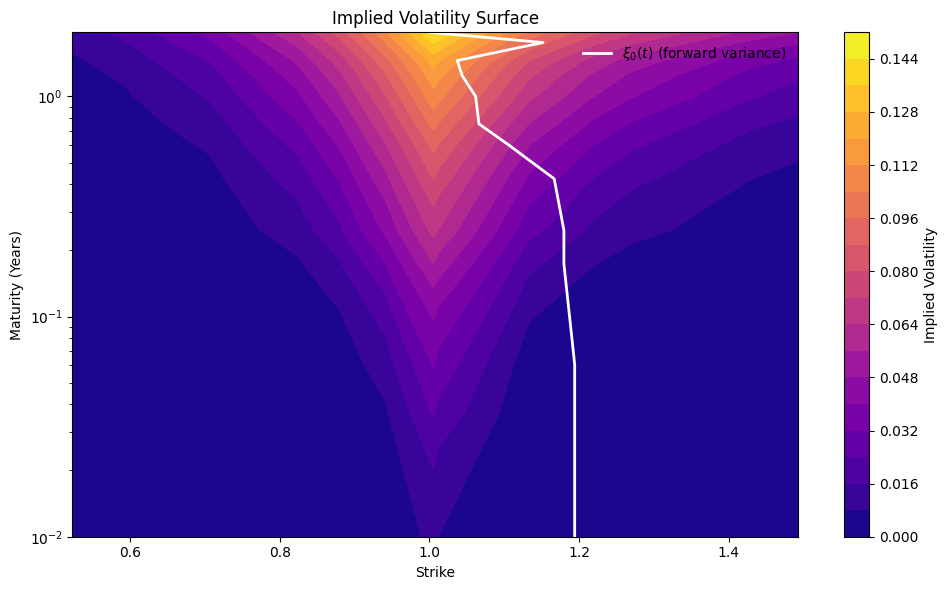

In [193]:
k = 10
xi0_knots = np.array(surfaces[k]["params"]["xi0_knots"])
maturities = np.array(surfaces[k]["grid"]["maturities"])

# interpolate xi0 to the maturity grid
xi0_interp = np.interp(
    maturities,
    np.linspace(maturities.min(), maturities.max(), len(xi0_knots)),
    xi0_knots
)

plot_iv_surface(
    #x,
    surfaces[k]["price_surface"],
    surfaces[k]["grid"]["strikes"],
    maturities,
    xi0_curve=xi0_interp,
    kind="contour"
)


In [171]:
import numpy as np

def fix_strike_outliers(surface, threshold_low=0.98, threshold_high=1.02, 
                        lift_strength=0.9, damp_strength=0.6, window=2):
    """
    Entfernt unphysikalische Dellen (Narben) und Spikes entlang der Strike-Achse.
    Arbeitet maturity-wise (Zeile für Zeile), respektiert lokale Smile-Struktur.

    Parameters
    ----------
    surface : np.ndarray
        2D implied volatility surface (maturities x strikes)
    threshold_low : float
        Faktor, ab wann ein Punkt als zu niedrig gilt (z.B. 0.85 → 15% unter Median)
    threshold_high : float
        Faktor, ab wann ein Punkt als zu hoch gilt (z.B. 1.2 → 20% über Median)
    lift_strength : float
        Stärke der Anhebung für Dellen (0.9 ≈ fast auf Median)
    damp_strength : float
        Stärke der Dämpfung für Spikes (0.6 ≈ teilweise auf Median zurück)
    window : int
        Lokale Nachbarschaft links/rechts für Median-Betrachtung

    Returns
    -------
    np.ndarray
        Surface mit korrigierten Strike-Anomalien
    """
    surface = np.array(surface, dtype=float)
    out = surface.copy()
    n_T, n_K = surface.shape

    for t in range(n_T):
        row = surface[t, :]
        corrected = row.copy()

        for i in range(n_K):
            left = max(0, i - window)
            right = min(n_K, i + window + 1)
            local = row[left:right]
            local_med = np.median(local)

            # Delle → anheben
            if row[i] < threshold_low * local_med:
                corrected[i] = row[i] + lift_strength * (local_med - row[i])
            # Spike → absenken
            elif row[i] > threshold_high * local_med:
                corrected[i] = row[i] - damp_strength * (row[i] - local_med)

        out[t, :] = corrected

    return out

x = fix_strike_outliers(surfaces[k]["iv_surface"])

In [21]:
# ============================================================
# Train the model
# ============================================================

# Prepare data loaders and collect normalization stats
train_loader, val_loader, branch_dim = DeepONet.prepare_data(surfaces, batch_size=256)

# Initialize and train model
model = DeepONet(branch_in_dim=branch_dim, trunk_in_dim=2, latent_dim=64, hidden_dim=64)
model._build_networks()

trainer = Trainer(model, train_loader, val_loader, lr=1e-3)
trainer.fit(epochs=20)

TypeError: IVSurfaceDataset.__init__() takes 4 positional arguments but 5 were given

In [23]:
surfaces[1094]#["iv_surface"]

{'set_id': 54,
 'fwd_id': 7,
 'grid_id': 0,
 'params': {'eta': 3.3985834980490424,
  'rho': -0.724599497156589,
  'H': 0.3542711359679975,
  'xi0_knots': array([0.04079845, 0.06634991, 0.13017165, 0.14460251, 0.13539671,
         0.05258773, 0.01292954, 0.03100921])},
 'grid': {'strikes': array([0.5       , 0.55234685, 0.73871633, 0.78777822, 0.93791268,
         0.99176743, 1.09385996, 1.24518597, 1.3485773 , 1.38759924,
         1.46940226]),
  'maturities': array([0.01      , 0.24725688, 0.45573107, 0.56831942, 0.88960491,
         1.09010035, 1.13954188, 1.4131606 , 1.57465332, 1.89724408,
         2.        ])},
 'price_surface': array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00, 9.21292749e-04, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [1.21879890e-06, 3.53704971e-06, 9.08490983e-05, 1.78245389e-04,
         2.76141857e-03, 1.32724906e-02, 1.62603672e-03, 1.99207259e-04,
        

In [23]:
surfaces[1094]["iv_surface"]

array([[2.45280976, 1.5625205 , 0.67223124, 0.39445114, 0.34530123,
        0.27559397, 0.19149234, 0.18803966, 0.18939097, 0.21463689,
        0.33457865, 0.54599372, 0.70581807, 0.97908337, 1.25234868],
       [1.4431788 , 0.95498591, 0.46679302, 0.29965566, 0.26881964,
        0.22670542, 0.17803681, 0.17660954, 0.17749512, 0.19216278,
        0.26104097, 0.38965871, 0.4809221 , 0.63118518, 0.78144826],
       [0.43354784, 0.34745132, 0.26135479, 0.20486017, 0.19233805,
        0.17781687, 0.16458129, 0.16517942, 0.16559926, 0.16968866,
        0.1875033 , 0.2333237 , 0.25602614, 0.28328699, 0.31054785],
       [0.39021228, 0.31842054, 0.24662879, 0.19893882, 0.18880923,
        0.17733854, 0.16771902, 0.16837862, 0.16860229, 0.17134254,
        0.18483591, 0.22190345, 0.24123048, 0.26459453, 0.28795858],
       [0.37378547, 0.30626287, 0.23874027, 0.19444508, 0.18503745,
        0.17452848, 0.16589415, 0.16482708, 0.16502556, 0.16749729,
        0.17913577, 0.2121063 , 0.22958708, 

MSE stats:
  mse_mean: nan
  mse_std: nan
  mse_max: nan
  rmse: nan
  mae: nan
  max_abs_error: nan
  max_error_location: {'maturity_index': 0, 'strike_index': 0, 'strike': 0.5280604017482772, 'maturity': 0.01}
MSE stats:
  mse_mean: nan
  mse_std: nan
  mse_max: nan
  rmse: nan
  mae: nan
  max_abs_error: nan
  max_error_location: {'maturity_index': 0, 'strike_index': 0, 'strike': 0.5027240974412414, 'maturity': 0.01}
MSE stats:
  mse_mean: nan
  mse_std: nan
  mse_max: nan
  rmse: nan
  mae: nan
  max_abs_error: nan
  max_error_location: {'maturity_index': 0, 'strike_index': 0, 'strike': 0.5, 'maturity': 0.01}
MSE stats:
  mse_mean: nan
  mse_std: nan
  mse_max: nan
  rmse: nan
  mae: nan
  max_abs_error: nan
  max_error_location: {'maturity_index': 0, 'strike_index': 0, 'strike': 0.5, 'maturity': 0.01}
MSE stats:
  mse_mean: nan
  mse_std: nan
  mse_max: nan
  rmse: nan
  mae: nan
  max_abs_error: nan
  max_error_location: {'maturity_index': 0, 'strike_index': 0, 'strike': 0.519840

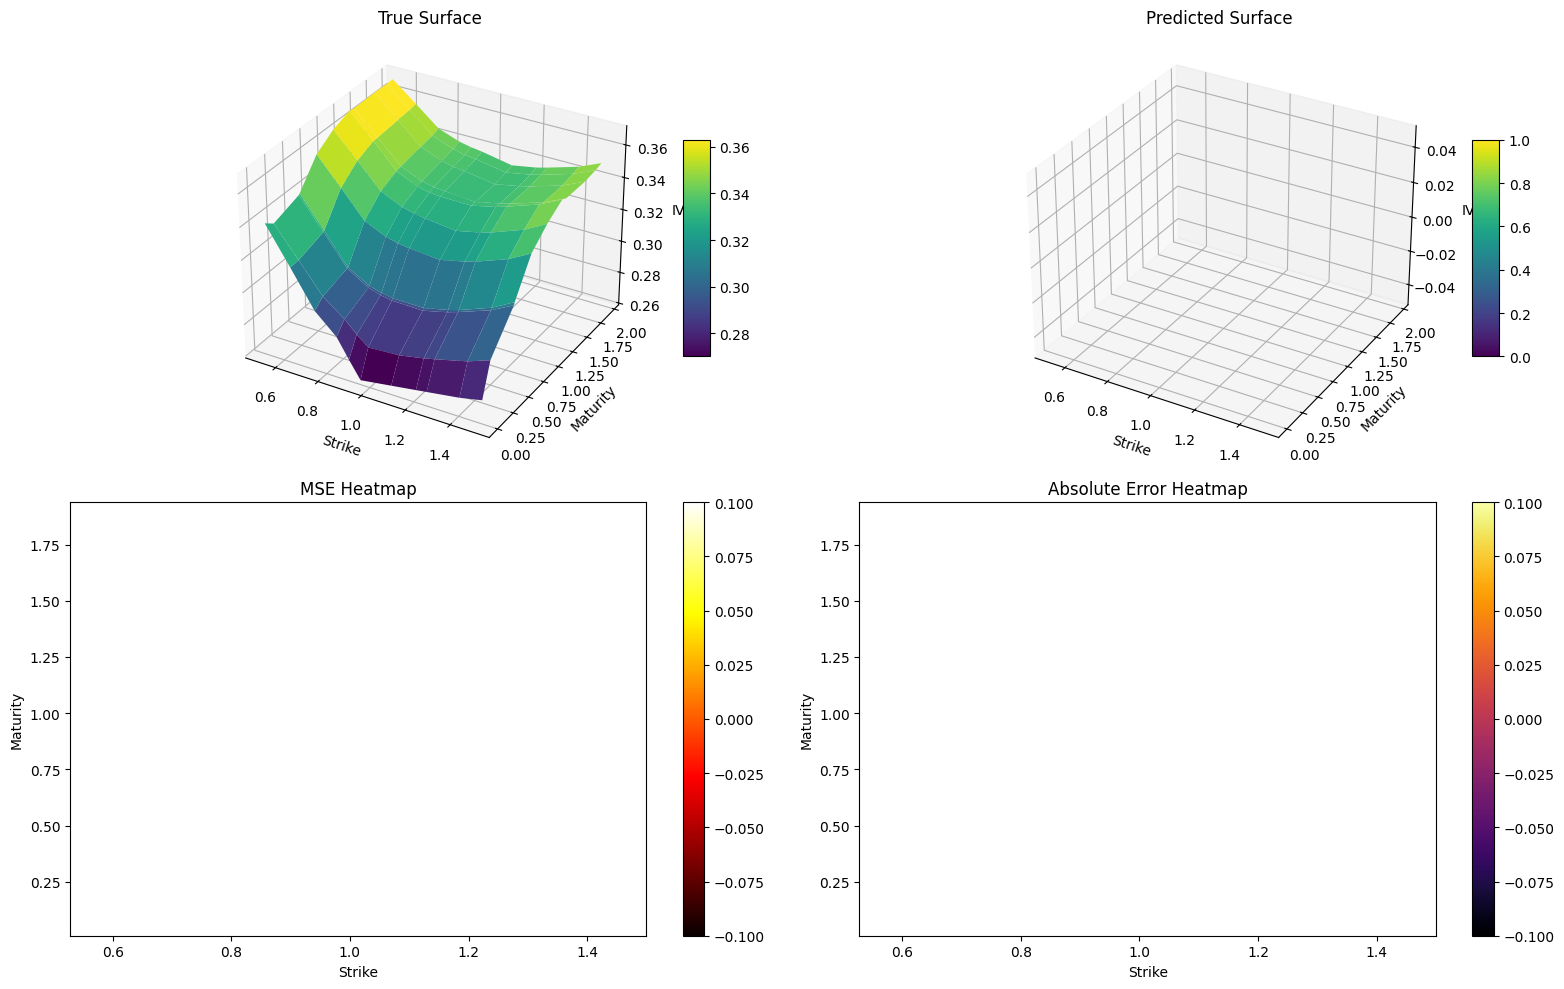

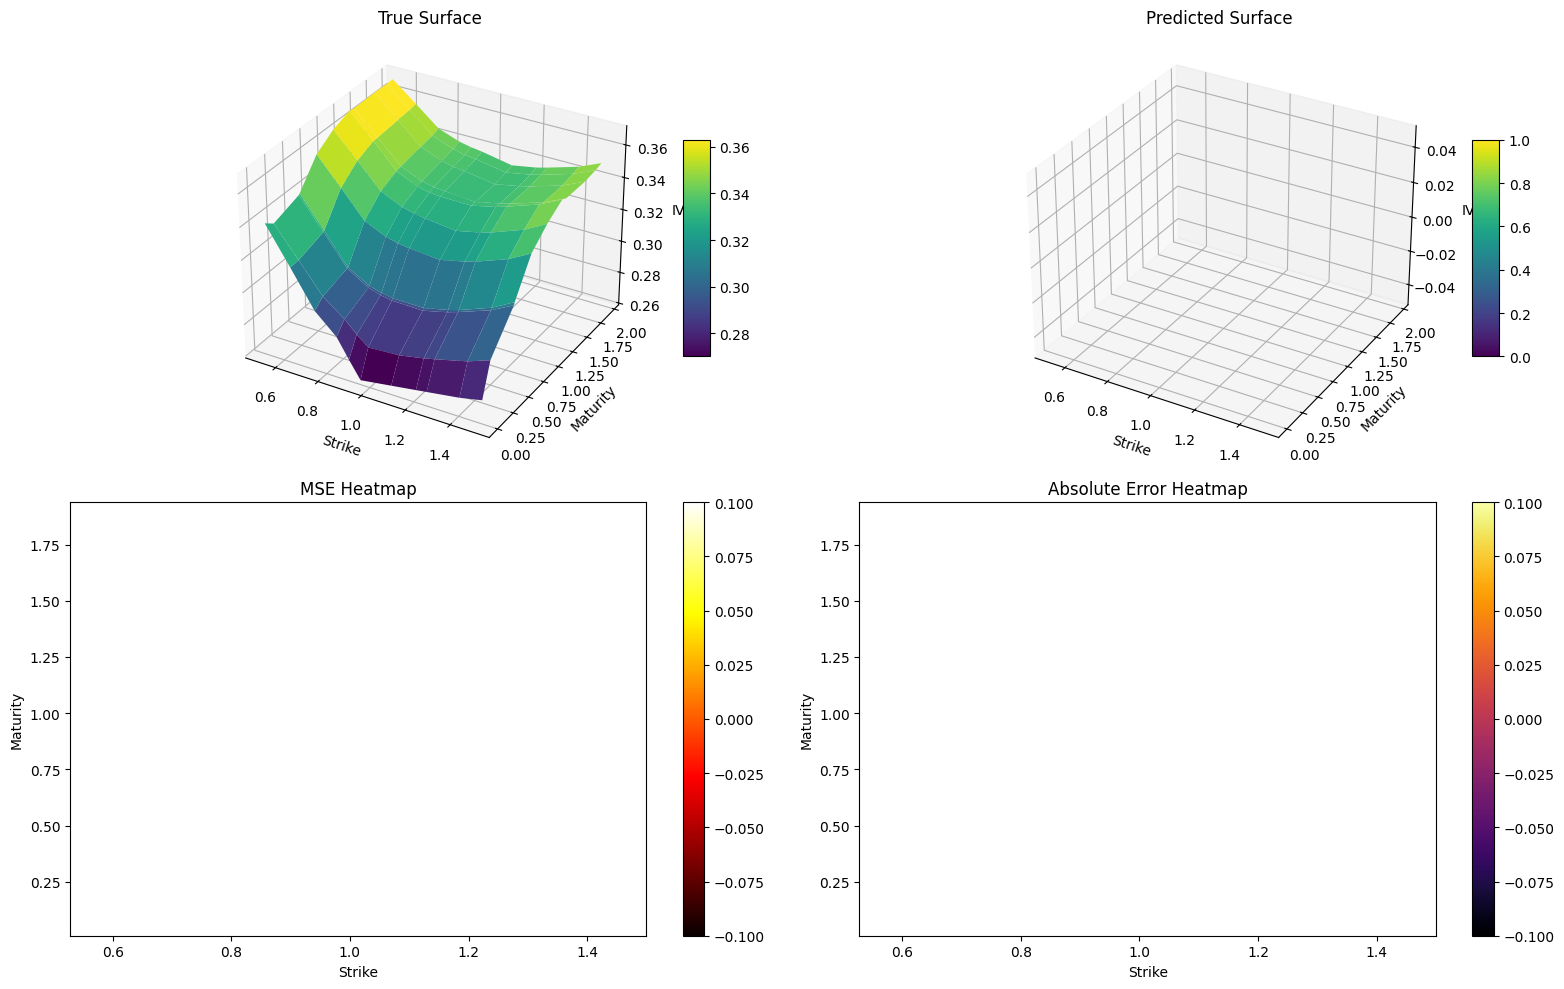

In [29]:
# ============================================================
# Evaluate the model
# ============================================================

# Create evaluator with training normalization stats
evaluator = ModelEvaluator(model)

# Select test samples for visualization
test_samples = surfaces[-5:]  # Use last 5 surfaces as test samples

# Create directory for evaluation plots
save_dir = os.path.join('data', datetime.now().strftime('%Y-%m-%d'), 'evaluation')
os.makedirs(save_dir, exist_ok=True)

# Generate evaluation plots
evaluator.evaluate_samples(test_samples, save_path=save_dir)
print(f"Evaluation plots saved to {save_dir}")

# Show an example plot in the notebook
evaluator.plot_evaluation(test_samples[0])  # Display first test sample's evaluation

# Consistency check 

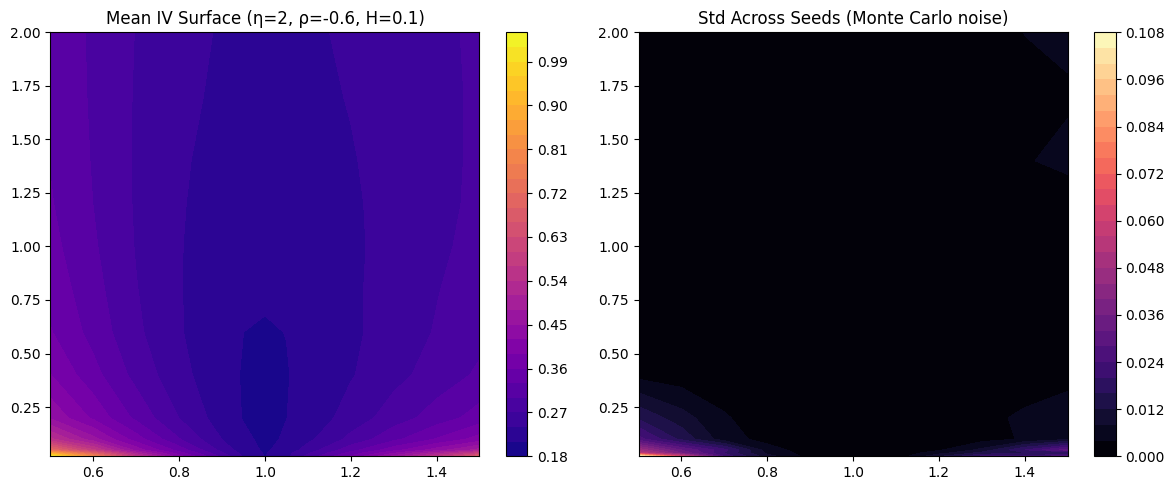

Average std across surface: 0.0057019994187229315


In [1]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import matplotlib.pyplot as plt
import numpy as np
from generation.surface_generation import generate_fixed_surface, SimulationConfig


cfg = SimulationConfig(M=50000, n=2*356, T_max=2.0, S0=1.0, G=1)

# Fixed params and xi₀ curve
param_set = {"eta": 2, "rho": -0.6, "H": 0.1}
xi0_knots = np.array([0.05, 0.06, 0.07, 0.08, 0.09, 0.10, 0.11, 0.12])  # deterministic forward var curve

num_seeds = 5
base_seed = 41

# Run ensemble
iv_surfaces = []
for s in range(num_seeds):
    surf = generate_fixed_surface(param_set, xi0_knots, cfg, seed=base_seed + s * 1000)
    iv_surfaces.append(surf["iv_surface"])

iv_stack = np.stack(iv_surfaces)
iv_mean = iv_stack.mean(axis=0)
iv_std = iv_stack.std(axis=0)

# Plot consistency
K, T = np.meshgrid(cfg.strikes, cfg.maturities)
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
c1 = axs[0].contourf(K, T, iv_mean, levels=30, cmap="plasma")
axs[0].set_title(f"Mean IV Surface (η={param_set['eta']}, ρ={param_set['rho']}, H={param_set['H']})")
plt.colorbar(c1, ax=axs[0])
c2 = axs[1].contourf(K, T, iv_std, levels=30, cmap="magma")
axs[1].set_title("Std Across Seeds (Monte Carlo noise)")
plt.colorbar(c2, ax=axs[1])
plt.tight_layout()
plt.show()

print("Average std across surface:", np.mean(iv_std))



In [3]:
first_rows = [surf[1, :] for surf in iv_surfaces]
first_rows 

[array([0.80982679, 0.63659507, 0.46336335, 0.37107391, 0.2734084 ,
        0.22942367, 0.20784316, 0.23012717, 0.26640057, 0.33816423,
        0.41302729, 0.49186291, 0.58770899]),
 array([0.9029142 , 0.69962543, 0.49633665, 0.37271176, 0.27265018,
        0.22940339, 0.20696652, 0.22843921, 0.26459477, 0.34058233,
        0.4170969 , 0.49735929, 0.57893052]),
 array([0.82230516, 0.65706668, 0.4918282 , 0.36414997, 0.27226361,
        0.2291802 , 0.20676618, 0.22803386, 0.26483209, 0.35239469,
        0.44197546, 0.52254053, 0.60310559]),
 array([0.84182963, 0.67635755, 0.51088548, 0.37404985, 0.27617819,
        0.23262777, 0.20660174, 0.22945029, 0.26537828, 0.33280482,
        0.40153589, 0.47446789, 0.56287218]),
 array([0.96053349, 0.74090011, 0.52126672, 0.38646083, 0.27738189,
        0.23064848, 0.20777998, 0.2312901 , 0.26704344, 0.33827381,
        0.41278599, 0.49599724, 0.58424685])]